In [3]:
!pip install google_play_scraper
!pip install textblob

You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [10]:
!pip install matplotlib

You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [4]:
from google_play_scraper import app , Sort , reviews_all
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as dates

In [5]:
nhs_reviews = reviews_all(
    'com.microsoft.planner',
    sleep_milliseconds=0,
    lang='en',
    sort=Sort.NEWEST
)

In [6]:
print(nhs_reviews[:5])

[{'reviewId': '4ffe5822-3388-42d6-b0aa-0b637d397320', 'userName': 'Matthew Pieterse', 'userImage': 'https://play-lh.googleusercontent.com/a-/ALV-UjV-BGj8v0DGBN9R7-6P8UaXlhoU2PjWKVTPs4Rqy-ZVxm_s5m4z-w', 'content': 'Lagging far behind the desktop/web UI experience. The mobile version is very unappealing and painful to navigate.', 'score': 1, 'thumbsUpCount': 0, 'reviewCreatedVersion': '1.18.36', 'at': datetime.datetime(2026, 3, 24, 22, 39, 25), 'replyContent': None, 'repliedAt': None, 'appVersion': '1.18.36'}, {'reviewId': '12098749-597c-4c0c-afbd-ee6285b78449', 'userName': 'Ephraim Nkemachor', 'userImage': 'https://play-lh.googleusercontent.com/a-/ALV-UjUx0RR2ax3Vf0GmZVQaVHhxIxls02V7pXXPUnvmeQj6YXilAMxxgg', 'content': 'interface barely ever works', 'score': 1, 'thumbsUpCount': 0, 'reviewCreatedVersion': '1.18.31', 'at': datetime.datetime(2026, 3, 23, 22, 1, 55), 'replyContent': None, 'repliedAt': None, 'appVersion': '1.18.31'}, {'reviewId': '0241cd90-484f-442d-86ad-0b84b6d865f6', 'userN

In [8]:
df_nhsrev = pd.DataFrame(np.array(nhs_reviews),columns=['content'])
df_nhsrev = df_nhsrev.join(pd.DataFrame(df_nhsrev.pop('content').tolist()))
df_nhsrev.to_csv(r'C:\Users\USER\Documents\PBA\Week2\Scrapping_sentimentAnalysis_Assignment\df_plannerReview.csv',index=False)
df_nhsrev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,4ffe5822-3388-42d6-b0aa-0b637d397320,Matthew Pieterse,https://play-lh.googleusercontent.com/a-/ALV-U...,Lagging far behind the desktop/web UI experien...,1,0,1.18.36,2026-03-24 22:39:25,None,NaT,1.18.36
1,12098749-597c-4c0c-afbd-ee6285b78449,Ephraim Nkemachor,https://play-lh.googleusercontent.com/a-/ALV-U...,interface barely ever works,1,0,1.18.31,2026-03-23 22:01:55,None,NaT,1.18.31
2,0241cd90-484f-442d-86ad-0b84b6d865f6,딸기,https://play-lh.googleusercontent.com/a/ACg8oc...,it's good but hope there'll be notification fe...,4,0,None,2026-03-12 09:21:46,None,NaT,None
3,d5a759cd-b785-4818-a4ea-f80ee119074e,Tom O,https://play-lh.googleusercontent.com/a/ACg8oc...,I can only see one of many plans,1,0,1.18.36,2026-03-11 05:14:39,None,NaT,1.18.36
4,f5a76d6b-6e4c-44da-b1a6-d1cdb641ec59,Roke Beedell (RokeJulianLockhart),https://play-lh.googleusercontent.com/a-/ALV-U...,Does not integrate with To-Do.,2,0,None,2026-03-09 18:37:37,None,NaT,None


In [9]:
#clean the content column (impossible because we cannot control people's reviews) 
# EDA (Explnatory Data Analysis ) 
#1. size of the data :
def shape(df):
    rows,col = df.shape
    print(f"the dataset contains {rows} reviews and {col} columns.")
shape(df_nhsrev)

the dataset contains 2843 reviews and 11 columns.


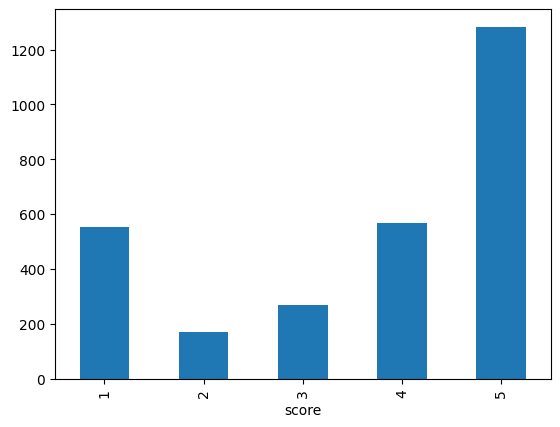

In [10]:
#2. rating distribution : to evaluate the order through the data score. 
#It is stated the valued for the highest stake comes down at 1 rating (39.74%) while the lowest at 4 rating (8.78%). 
df_rating = df_nhsrev["score"].value_counts().sort_index().plot(kind="bar")



In [11]:
def rating_summarize(df): 
    rating_score = df_nhsrev['score'].value_counts().sort_index()
    total = len(df)

    for rating, count in rating_score.items():
         percent = round((count/total)*100,2)
         print(f"{rating} star : {count} reviews ({percent}%)")
rating_summarize(df_nhsrev)

1 star : 553 reviews (19.45%)
2 star : 170 reviews (5.98%)
3 star : 270 reviews (9.5%)
4 star : 567 reviews (19.94%)
5 star : 1283 reviews (45.13%)


In [12]:
df_nhsrev["review_length"] = df_nhsrev.content.str.len()
df_nhsrev["review_length"].describe()

count    2843.000000
mean       87.628210
std        97.099048
min         1.000000
25%        22.000000
50%        55.000000
75%       116.000000
max       931.000000
Name: review_length, dtype: float64

In [13]:
#3. Checking most common words 
all_text = " ".join(df_nhsrev["content"].astype(str))
print(all_text[:500])

Lagging far behind the desktop/web UI experience. The mobile version is very unappealing and painful to navigate. interface barely ever works it's good but hope there'll be notification feature for comment and things.. I can only see one of many plans Does not integrate with To-Do. Not compatible with premium plan. Useless app. Principally a good app but pretty much unusable if you're using more than one MS account on one device. For Word, Excel and other MS apps it's pretty eas to switch but no


In [14]:
#DATA PREPROCESSING
# Lower casing

# Change the reviews type to string
df_nhsrev['content'] = df_nhsrev['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_nhsrev['content'].head())

0    Lagging far behind the desktop/web UI experien...
1                          interface barely ever works
2    it's good but hope there'll be notification fe...
3                     I can only see one of many plans
4                       Does not integrate with To-Do.
Name: content, dtype: object


In [15]:
#lowercasing the reviews 
#Lowercase all reviews to see the difference
df_nhsrev['content']= df_nhsrev['content'].apply(lambda x: x.lower())
print(df_nhsrev['content'].head())

0    lagging far behind the desktop/web ui experien...
1                          interface barely ever works
2    it's good but hope there'll be notification fe...
3                     i can only see one of many plans
4                       does not integrate with to-do.
Name: content, dtype: object


In [16]:
#REMOVE PUNCTUATION 
import re

df_nhsrev["content"] = df_nhsrev["content"].apply(lambda x: re.sub(r"[^\w\s]", "", x))
print(df_nhsrev["content"].tail())

2838    limited functionality  cant add tasks or plans...
2839                                           works well
2840    fantastic this is what i was waiting for and i...
2841    a good first version excited for more planner ...
2842                                     clean and simple
Name: content, dtype: object


In [17]:
#REMOVE STOPWORDS
!pip install nltk
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
from nltk.corpus import stopwords
from nltk.probability import FreqDist
stop_words = set(stopwords.words("english"))

In [19]:
df_nhsrev["content"] = df_nhsrev["content"].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)

In [20]:
df_nhsrev["content"].tail()

2838    limited functionality cant add tasks plans nor...
2839                                           works well
2840                  fantastic waiting looks works great
2841      good first version excited planner capabilities
2842                                         clean simple
Name: content, dtype: object

In [23]:
df_nhsrev.to_csv(
r'C:\Users\USER\Documents\PBA\Week2\Scrapping_sentimentAnalysis_Assignment\planner_clean_reviews.csv', index=False
)

In [24]:
!pip install seaborn

In [25]:
#COUNT WORD FREQUENCY 

import seaborn as sns
import matplotlib.pyplot as plt
def freq_words(x, terms = 30):
    all_words = ''.join([text for text in x])
    all_words = all_words.split()

    fdist = FreqDist(all_words)
    words_df_nhsrev = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

    #Selecting top 20 most frequent words 
    
    d = words_df_nhsrev.nlargest(columns="count", n = terms)
    plt.figure(figsize=(20,5))
    ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")
    ax.set(ylabel="Count")
    plt.show()
    
    
    
    

C:\Users\USER\AppData\Local\Temp\ipykernel_29624\546779942.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")


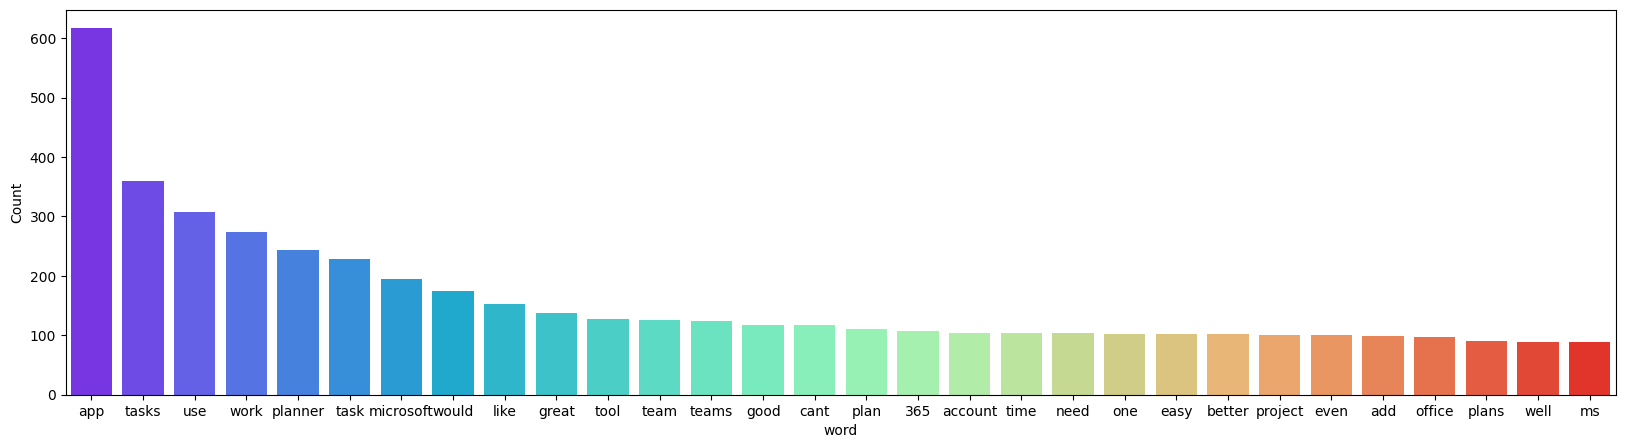

In [26]:
freq_words(df_nhsrev['content'])

In [27]:
!pip install textblob

In [30]:
from textblob import TextBlob

In [31]:
#Create Sentiment Function
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity


In [32]:
df_nhsrev["polarity"] = df_nhsrev["content"].apply(get_sentiment)


In [33]:
print(df_nhsrev[["content","polarity"]])

                                                content  polarity
0     lagging far behind desktopweb ui experience mo... -0.350000
1                           interface barely ever works  0.050000
2     good hope therell notification feature comment...  0.700000
3                                    see one many plans  0.500000
4                                        integrate todo  0.000000
...                                                 ...       ...
2838  limited functionality cant add tasks plans nor... -0.107143
2839                                         works well  0.000000
2840                fantastic waiting looks works great  0.600000
2841    good first version excited planner capabilities  0.441667
2842                                       clean simple  0.183333

[2843 rows x 2 columns]


In [34]:
def sentiment_label(score):
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

df_nhsrev["sentiment"] = df_nhsrev["polarity"].apply(sentiment_label)

In [35]:
df_nhsrev["sentiment"].value_counts()

sentiment
positive    1867
neutral      683
negative     293
Name: count, dtype: int64

<Axes: xlabel='sentiment'>

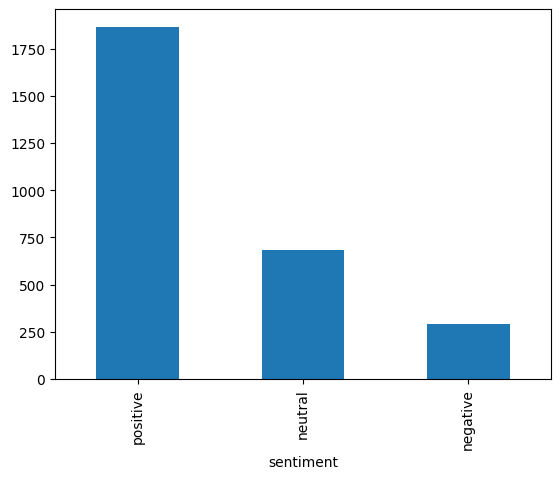

In [36]:
df_nhsrev["sentiment"].value_counts().plot(kind="bar")

In [42]:
#buat label 
import pandas as pd
df = pd.read_csv(r"C:\Users\USER\Documents\PBA\Week2\Scrapping_sentimentAnalysis_Assignment\planner_clean_na.csv")

df.head()



,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,review_length,sentiment
0,6d130fcb-47b1-42fc-a032-bf97719ca5a4,Alexander Benkstein,https://play-lh.googleusercontent.com/a-/ALV-U...,principally good app pretty much unusable your...,2,0,1.18.36,3/3/2026 15:08,NaN,NaN,1.18.36,190,NaN
1,34f4642b-17ee-463b-ac28-05a902db1cb9,Thomas Watson,https://play-lh.googleusercontent.com/a/ACg8oc...,like far ill report later,3,0,1.18.36,2/27/2026 11:03,NaN,NaN,1.18.36,42,NaN
2,5a9342d9-8259-4c6f-b8b8-20b1096cf69d,Matt Winter,https://play-lh.googleusercontent.com/a-/ALV-U...,would load real assistance common days easier ...,1,1,1.18.36,2/27/2026 5:43,NaN,NaN,1.18.36,257,NaN
3,73a714db-ceb1-4b5d-a1af-64d953643ad9,Hugo Arista,https://play-lh.googleusercontent.com/a/ACg8oc...,experience app really good thing tools availab...,4,0,1.18.36,2/24/2026 23:49,NaN,NaN,1.18.36,252,NaN
4,79b2321f-1e26-4028-b553-da8b0d8896b4,Laura R,https://play-lh.googleusercontent.com/a-/ALV-U...,app complete failure planner used kanban board...,1,1,1.18.33,2/17/2026 5:10,NaN,NaN,1.18.33,490,NaN


In [44]:
#search for the score number exist
print(df[["content","score"]])



                                                content  score
0     principally good app pretty much unusable your...      2
1                             like far ill report later      3
2     would load real assistance common days easier ...      1
3     experience app really good thing tools availab...      4
4     app complete failure planner used kanban board...      1
...                                                 ...    ...
2825  limited functionality cant add tasks plans nor...      2
2826                                         works well      5
2827                fantastic waiting looks works great      5
2828    good first version excited planner capabilities      5
2829                                       clean simple      5

[2830 rows x 2 columns]


In [59]:

#make a label : 
# Percent	Label
# ≥50	positive
# 40–49	neutral
# <40	negative

def sentiment_label(score):
    if score > 3:
        return("positive")
    elif score < 3:
        return("negative")
    else:
        return("neutral")
    df["sentiment"] = df["score"].apply(sentiment_label)
    return df
print(df)

                                  reviewId             userName  \
0     6d130fcb-47b1-42fc-a032-bf97719ca5a4  Alexander Benkstein   
1     34f4642b-17ee-463b-ac28-05a902db1cb9        Thomas Watson   
2     5a9342d9-8259-4c6f-b8b8-20b1096cf69d          Matt Winter   
3     73a714db-ceb1-4b5d-a1af-64d953643ad9          Hugo Arista   
4     79b2321f-1e26-4028-b553-da8b0d8896b4              Laura R   
...                                    ...                  ...   
2825  318d375e-2bdc-47c3-b7a7-02fd990b5f98        A Google user   
2826  b1724cc5-74ad-4ec7-a344-a80ba3d618f9        A Google user   
2827  bf702dd6-0905-45ac-bcec-a5f06e85cfc7        A Google user   
2828  092720c3-756b-47b0-bde7-3b8d36e3527c        A Google user   
2829  e530c92a-e786-4239-b8b2-2ccc11240253        A Google user   

                                              userImage  \
0     https://play-lh.googleusercontent.com/a-/ALV-U...   
1     https://play-lh.googleusercontent.com/a/ACg8oc...   
2     https://play

In [61]:
df.to_csv(r"C:\Users\USER\Documents\PBA\Week3\1_exercise_Individual_labelling\labelling.csv", index=False)